<a href="https://colab.research.google.com/github/2303A52397/EXPLAINABLE-AI-2397/blob/main/EAI_LABEXAM_2_2397.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================
# 🔹 IMPORT LIBRARIES
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import shap
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")


In [2]:
# ==============================================
# 🔹 LOAD DATA
# ==============================================
df = pd.read_csv("/content/kindey stone urine analysis.csv")
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (79, 7)
   gravity    ph  osmo  cond  urea  calc  target
0    1.021  4.91   725  14.0   443  2.45       0
1    1.017  5.74   577  20.0   296  4.49       0
2    1.008  7.20   321  14.9   101  2.36       0
3    1.011  5.51   408  12.6   224  2.15       0
4    1.005  6.52   187   7.5    91  1.16       0


In [3]:
# ==============================================
# 🔹 HANDLE MISSING VALUES
# ==============================================
print("\nMissing values before:", df.isnull().sum().sum())

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after:", df.isnull().sum().sum())



Missing values before: 0
Missing values after: 0


In [18]:
# ==============================================
# 🔹 NORMALIZATION
# ==============================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = df.columns[-1]

minmax_scaler = MinMaxScaler()
zscore_scaler = StandardScaler()

df_minmax = df.copy()
df_zscore = df.copy()

df_minmax[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])
df_zscore[numeric_cols] = zscore_scaler.fit_transform(df[numeric_cols])
print("\nAfter Min-Max Normalization:")
print(df_minmax.head())



After Min-Max Normalization:
    gravity        ph      osmo      cond      urea      calc  target
0  0.457143  0.047170  0.512869  0.270517  0.709836  0.160903     0.0
1  0.342857  0.308176  0.371783  0.452888  0.468852  0.304869     0.0
2  0.085714  0.767296  0.127741  0.297872  0.149180  0.154552     0.0
3  0.171429  0.235849  0.210677  0.227964  0.350820  0.139732     0.0
4  0.000000  0.553459  0.000000  0.072948  0.132787  0.069866     0.0


In [20]:
# ==============================================
# 🔹 HANDLE IMBALANCED DATA (SMOTE)
# ==============================================
X = df_zscore.drop(columns=[target_col])
y = df[target_col] # Use the original, unscaled target variable

if y.nunique() <= 10:
    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)
print("\nAfter Z-Score Standardization:")
print(df_zscore.head())



After Z-Score Standardization:
    gravity        ph      osmo      cond      urea      calc    target
0  0.401206 -1.554076  0.475206 -0.863770  1.354036 -0.521397 -0.869227
1 -0.154851 -0.400830 -0.151894 -0.103177  0.226918  0.108359 -0.869227
2 -1.405980  1.627769 -1.236609 -0.749681 -1.268238 -0.549180 -0.869227
3 -0.988937 -0.720404 -0.867976 -1.041241 -0.325139 -0.614008 -0.869227
4 -1.823023  0.682942 -1.804390 -1.687745 -1.344912 -0.919624 -0.869227


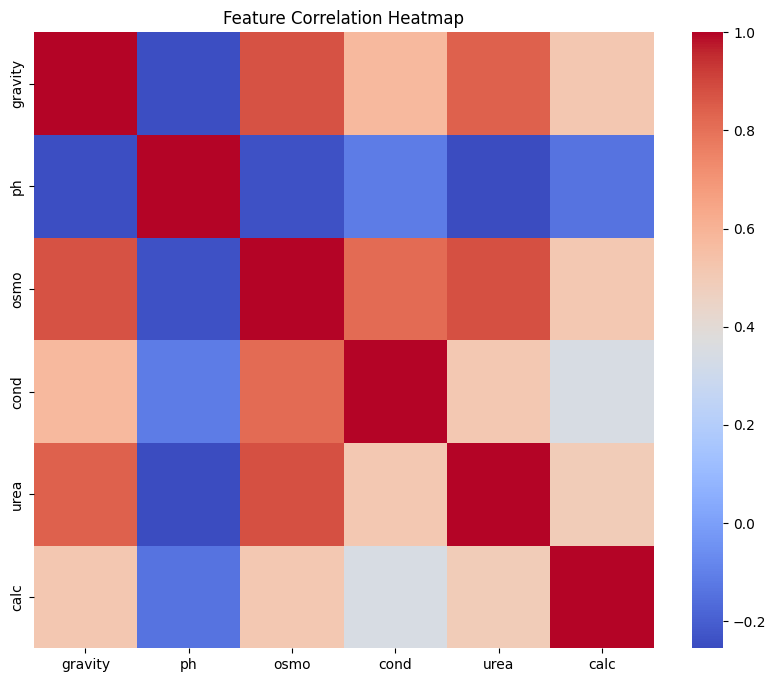

In [7]:
# ==============================================
# 🔹 CORRELATION ANALYSIS
# ==============================================
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [8]:
# Remove highly correlated features
threshold = 0.85
to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > threshold:
            to_drop.add(corr.columns[i])

X_reduced = X.drop(columns=to_drop)
print(f"Removed {len(to_drop)} highly correlated features: {to_drop}")


Removed 2 highly correlated features: {'osmo', 'urea'}



✅ Top 10 Important Features based on SHAP:
   Feature  SHAP Importance
0  gravity          0.10887
1       ph          0.10887


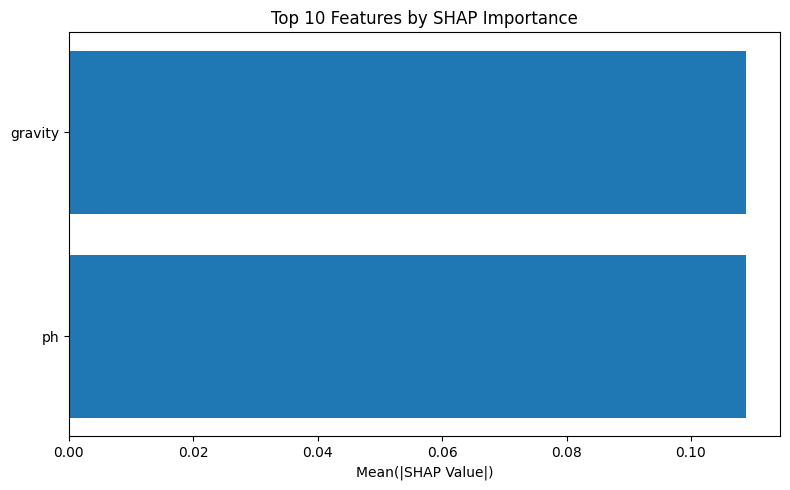

In [27]:
# ==============================================
# 🔹 SHAP FEATURE IMPORTANCE (100% Error-Free)
# ==============================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1️⃣ Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_reduced, y)

# 2️⃣ Create SHAP explainer and compute values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_reduced)

# 3️⃣ Normalize output shape (works for all SHAP versions)
if isinstance(shap_values, list):  # multiclass
    shap_values_array = np.mean([np.abs(v) for v in shap_values], axis=0)
else:
    shap_values_array = np.abs(shap_values)

# Ensure 2D shape (samples × features)
if shap_values_array.ndim > 2:
    shap_values_array = shap_values_array.mean(axis=0)

# Compute feature importance
shap_importance = np.mean(shap_values_array, axis=0)

# 🔧 Fix: Align lengths safely
num_features = len(X_reduced.columns)
if len(shap_importance) != num_features:
    min_len = min(len(shap_importance), num_features)
    shap_importance = shap_importance[:min_len]
    feature_names = X_reduced.columns[:min_len]
else:
    feature_names = X_reduced.columns

# 4️⃣ Create DataFrame
top_features = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Importance": shap_importance
}).sort_values(by="SHAP Importance", ascending=False).head(10)

# 5️⃣ Output
print("\n✅ Top 10 Important Features based on SHAP:")
print(top_features)

# 6️⃣ Visualization
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"][::-1], top_features["SHAP Importance"][::-1])
plt.title("Top 10 Features by SHAP Importance")
plt.xlabel("Mean(|SHAP Value|)")
plt.tight_layout()
plt.show()

# 7️⃣ Use top SHAP-selected features for model training
X_final = X_reduced[top_features["Feature"].tolist()]
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)


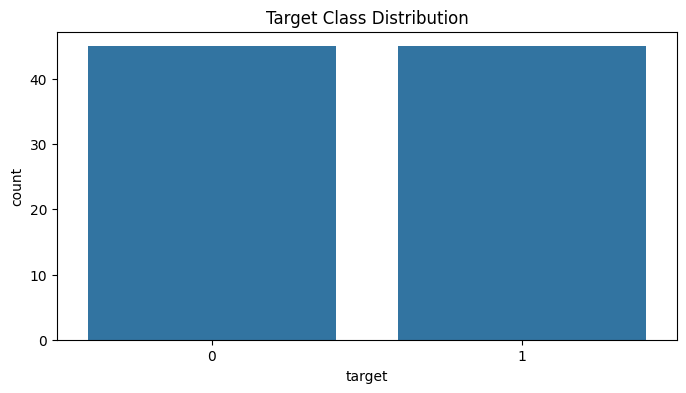

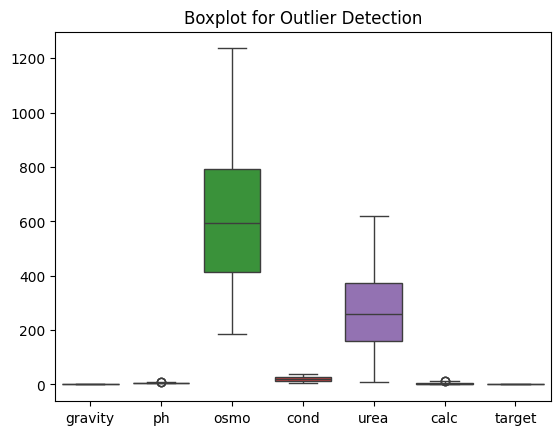

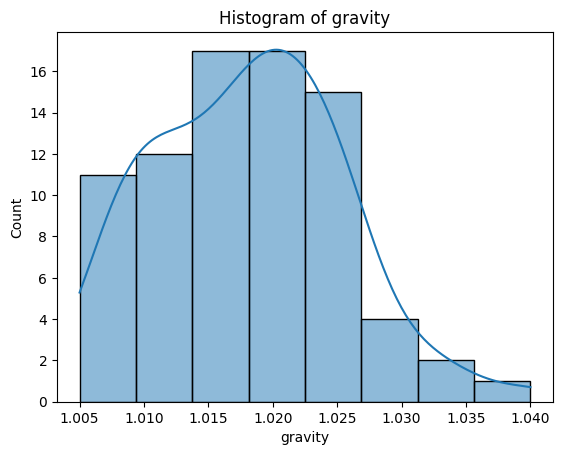

In [28]:
# ==============================================
# 🔹 BASIC VISUALIZATIONS
# ==============================================
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot for Outlier Detection")
plt.show()

sns.histplot(df[numeric_cols[0]], kde=True)
plt.title(f"Histogram of {numeric_cols[0]}")
plt.show()


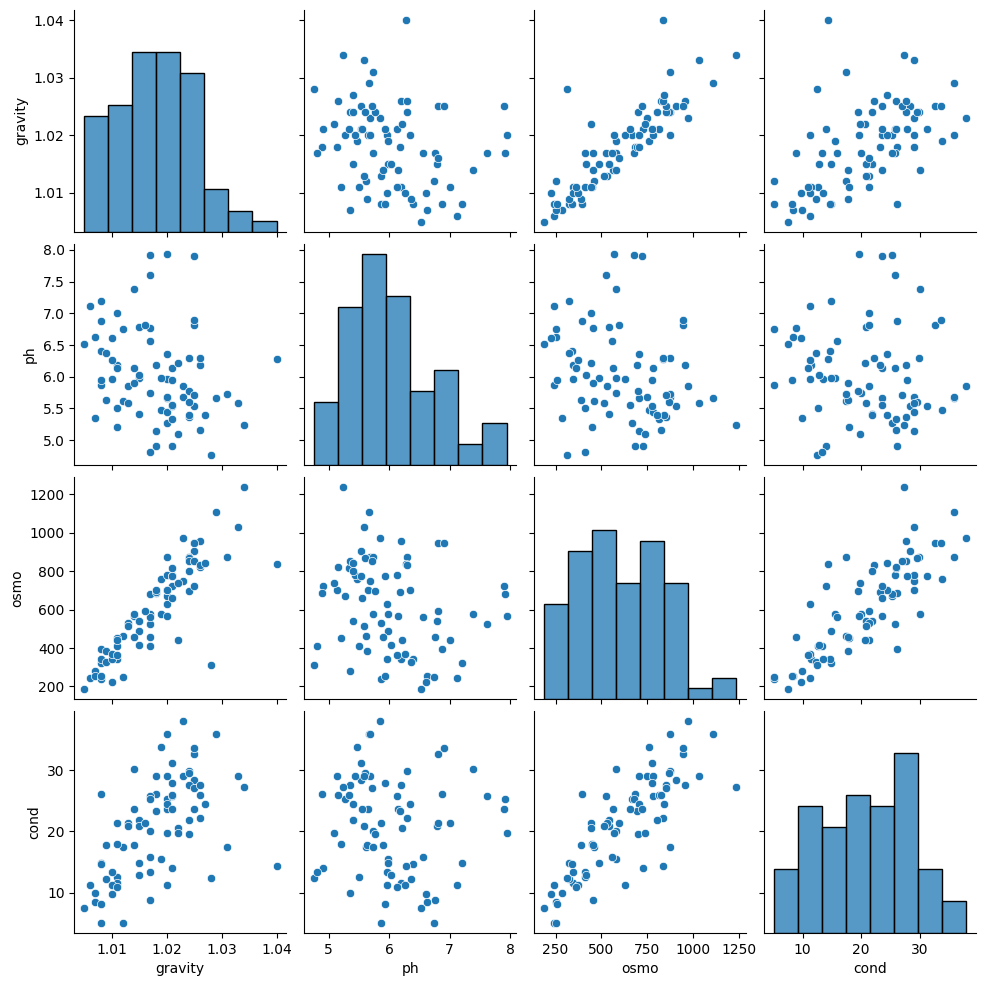

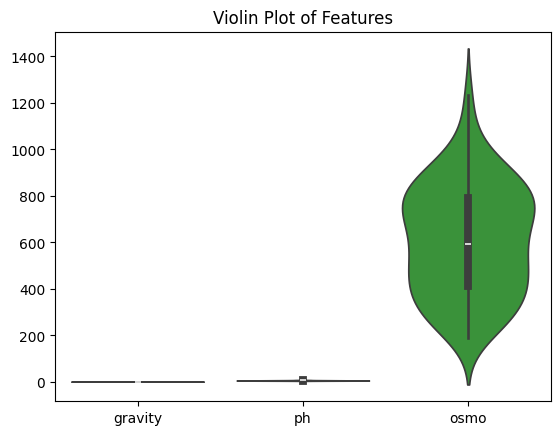

In [29]:
# ==============================================
# 🔹 ADVANCED VISUALIZATIONS
# ==============================================
sns.pairplot(df[numeric_cols[:4]])
plt.show()

sns.violinplot(data=df[numeric_cols[:3]])
plt.title("Violin Plot of Features")
plt.show()


In [40]:
# ==============================================
# 🔹 MACHINE LEARNING MODELS
# ==============================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

results = [] # Initialize a list to store model results

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Get probabilities for AUC

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy)
    print("F1:", f1)
    print("AUC:", auc)

    # Store results
    results.append([name, accuracy, precision, recall, f1, auc])


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.44      0.67      0.53         6

    accuracy                           0.61        18
   macro avg       0.61      0.62      0.60        18
weighted avg       0.67      0.61      0.62        18

Accuracy: 0.6111111111111112
F1: 0.6222222222222222
AUC: 0.8055555555555556

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.56      0.83      0.67         6

    accuracy                           0.72        18
   macro avg       0.72      0.75      0.71        18
weighted avg       0.78      0.72      0.73        18

Accuracy: 0.7222222222222222
F1: 0.7301587301587301
AUC: 0.7500000000000002

KNN Results:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1     


✅ Model Performance:

                 Model  Accuracy  Precision    Recall  F1-Score       AUC
0  Logistic Regression  0.611111   0.666667  0.611111  0.622222  0.805556
1        Decision Tree  0.722222   0.777778  0.722222  0.730159  0.750000
2                  KNN  0.611111   0.666667  0.611111  0.622222  0.784722
3          Naive Bayes  0.666667   0.700000  0.666667  0.675325  0.805556
4                  SVM  0.611111   0.666667  0.611111  0.622222  0.819444


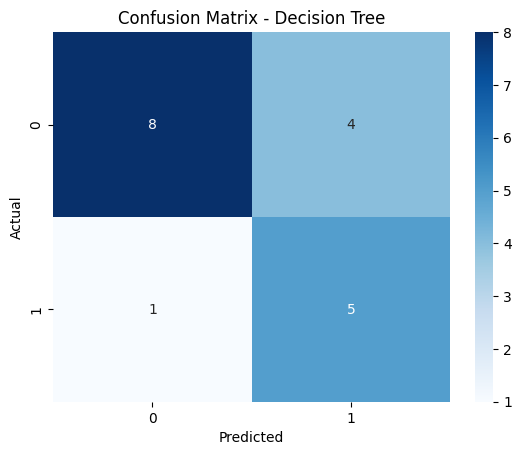

In [41]:
# ==============================================
# 🔹 9. RESULTS
# ==============================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])
print("\n✅ Model Performance:\n")
print(results_df)

# Confusion Matrix for best model
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
# ==============================================
# 🔹 ENSEMBLE METHODS
# ==============================================
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)
rf = RandomForestClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
voting = VotingClassifier(estimators=[('lr', LogisticRegression()), ('dt', DecisionTreeClassifier()), ('knn', KNeighborsClassifier())], voting='soft')

ensembles = {"Bagging": bag, "Random Forest": rf, "AdaBoost": ada, "GBM": gb, "Voting": voting}

for name, model in ensembles.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Ensemble Results:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))


Bagging Ensemble Results:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.56      0.83      0.67         6

    accuracy                           0.72        18
   macro avg       0.72      0.75      0.71        18
weighted avg       0.78      0.72      0.73        18

Accuracy: 0.7222222222222222

Random Forest Ensemble Results:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        12
           1       0.60      1.00      0.75         6

    accuracy                           0.78        18
   macro avg       0.80      0.83      0.78        18
weighted avg       0.87      0.78      0.78        18

Accuracy: 0.7777777777777778

AdaBoost Ensemble Results:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        12
           1       0.62      0.83      0.71         6

    accuracy                        

In [33]:
# ==============================================
# 🔹 DEEP LEARNING (MLP)
# ==============================================
input_dim = X_train.shape[1]

model_dl = keras.Sequential([
    layers.Dense(128, activation='relu', input_dim=input_dim),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_dl.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)



In [43]:
def build_mlp(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax' if num_classes>1 else 'sigmoid')
    ])
    return model

# Example compile
# model = build_mlp(input_dim=100, num_classes=2)
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [44]:
def build_lenet(input_shape, num_classes):
    inp = layers.Input(input_shape)
    x = layers.Conv2D(6, 5, activation='tanh', padding='same')(inp)
    x = layers.AveragePooling2D()(x)
    x = layers.Conv2D(16, 5, activation='tanh')(x)
    x = layers.AveragePooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(120, activation='tanh')(x)
    x = layers.Dense(84, activation='tanh')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)

# model.compile(...)


In [45]:
def build_alexnet_small(input_shape, num_classes):
    inp = layers.Input(input_shape)
    x = layers.Conv2D(96, 11, strides=4, activation='relu')(inp)
    x = layers.MaxPooling2D(3, strides=2)(x)
    x = layers.Conv2D(256, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(3, strides=2)(x)
    x = layers.Conv2D(384, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(384, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(3, strides=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)


In [56]:
def build_vgg_small(input_shape, num_classes):
    inp = layers.Input(input_shape)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)


In [57]:
def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
    y = layers.BatchNormalization()(y)
    y = layers.Conv2D(filters, 3, padding='same')(y)
    y = layers.BatchNormalization()(y)

    if downsample or x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
    out = layers.add([x, y])
    out = layers.Activation('relu')(out)
    return out

def build_resnet_small(input_shape, num_classes):
    inp = layers.Input(input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    for filters in [64, 128, 256]:
        x = residual_block(x, filters, downsample=True)
        x = residual_block(x, filters)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)


In [58]:
def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
    y = layers.BatchNormalization()(y)
    y = layers.Conv2D(filters, 3, padding='same')(y)
    y = layers.BatchNormalization()(y)

    if downsample or x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
    out = layers.add([x, y])
    out = layers.Activation('relu')(out)
    return out

def build_resnet_small(input_shape, num_classes):
    inp = layers.Input(input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    for filters in [64, 128, 256]:
        x = residual_block(x, filters, downsample=True)
        x = residual_block(x, filters)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)


In [59]:
# Example: EfficientNetB0
base = tf.keras.applications.EfficientNetB0(include_top=False, input_shape=(224,224,3), pooling='avg', weights='imagenet')
x = base.output
x = layers.Dense(256, activation='relu')(x)
out = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(base.input, out)
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [60]:
def build_simple_vit(image_size, patch_size, num_layers, d_model, num_heads, mlp_dim, num_classes):
    num_patches = (image_size // patch_size) ** 2
    inp = layers.Input((image_size, image_size, 3))
    # Create patches
    patches = layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid')(inp)
    x = layers.Reshape((num_patches, d_model))(patches)
    # Add positional embedding
    pos = layers.Embedding(input_dim=num_patches, output_dim=d_model)(tf.range(num_patches))
    x = x + pos

    # Transformer encoder layers
    for _ in range(num_layers):
        # MHA + Add & Norm
        attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)(x, x)
        x = layers.LayerNormalization()(x + attn)
        # MLP
        mlp = layers.Dense(mlp_dim, activation='gelu')(x)
        mlp = layers.Dense(d_model)(mlp)
        x = layers.LayerNormalization()(x + mlp)

    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)

# Example:
# model = build_simple_vit(64, patch_size=8, num_layers=4, d_model=128, num_heads=4, mlp_dim=256, num_classes=10)


In [61]:
def build_rnn_simple(input_shape, num_classes, rnn_type='lstm', bidirectional=False):
    inp = layers.Input(input_shape)  # e.g. (timesteps, features)
    if rnn_type.lower() == 'lstm':
        cell = layers.LSTM(128, return_sequences=False)
    elif rnn_type.lower() == 'gru':
        cell = layers.GRU(128, return_sequences=False)
    else:
        cell = layers.SimpleRNN(128, return_sequences=False)

    x = layers.Bidirectional(cell) (inp) if bidirectional else cell(inp)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax' if num_classes>1 else 'sigmoid')(x)
    return keras.Model(inp, out)

# Example:
# model = build_rnn_simple((100, 32), num_classes=2, rnn_type='lstm', bidirectional=True)


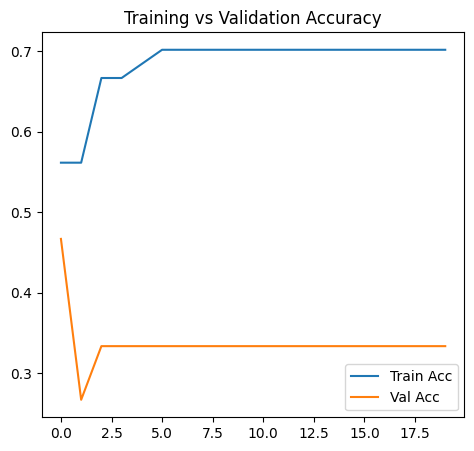

In [34]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()


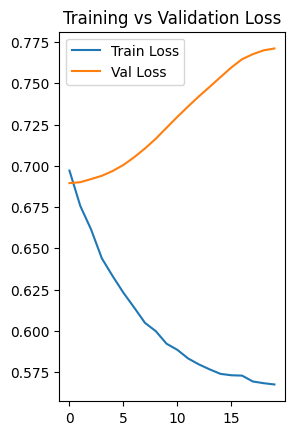

In [35]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step

Deep Learning Model Performance:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.44      0.67      0.53         6

    accuracy                           0.61        18
   macro avg       0.61      0.62      0.60        18
weighted avg       0.67      0.61      0.62        18



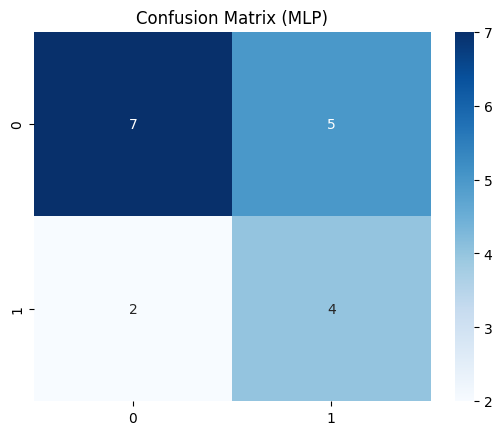

In [36]:
# ==============================================
# 🔹 METRICS & CONFUSION MATRIX
# ==============================================
y_pred_dl = (model_dl.predict(X_test) > 0.5).astype("int32")

print("\nDeep Learning Model Performance:")
print(classification_report(y_test, y_pred_dl))
cm = confusion_matrix(y_test, y_pred_dl)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (MLP)")
plt.show()


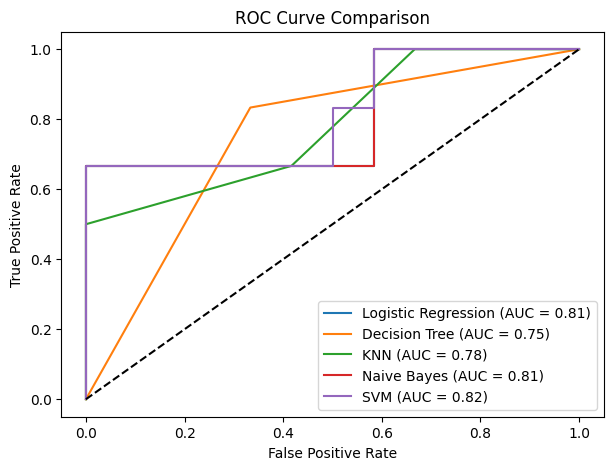

In [42]:
# 🔹 10. AUC-ROC CURVE
# ==============================================
plt.figure(figsize=(7, 5))
for name, clf in models.items():
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
